In [8]:
"""
Author: Maria (mariabaumg)
"""


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import random

# Setting seeds for reproducibility
random.seed(10)
torch.manual_seed(10)

In [9]:
features_list = [
    'lat', 'long', 'month', 'day_of_week', 'hour', 'is_weekend', 
    'lag_1h_inflow', 'lag_24h_inflow', 'lag_1h_outflow', 'lag_24h_outflow'
]

# generate mock data
np.random.seed(42)
samples = 2000

data = {
    'lat': np.random.uniform(40.6, 40.8, samples),
    'long': np.random.uniform(-74.0, -73.9, samples),
    'month': np.random.randint(1, 13, samples),
    'day_of_week': np.random.randint(0, 7, samples),
    'hour': np.random.randint(0, 24, samples),
    'is_weekend': np.random.randint(0, 2, samples),
    'lag_1h_inflow': np.random.poisson(5, samples),
    'lag_24h_inflow': np.random.poisson(5, samples),
    'lag_1h_outflow': np.random.poisson(5, samples),
    'lag_24h_outflow': np.random.poisson(5, samples)
}

# target
data['in_flow'] = np.random.poisson(5, samples)

df = pd.DataFrame(data)

# scale and convert to tensors
X = df[features_list].values
y = df['in_flow'].values

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

# scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# convert to PyTorch Tensors
x_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
x_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

print(f"Input shape: {x_train_t.shape}")
print(f"Features being used: {features_list}")

Input shape: torch.Size([1600, 10])
Features being used: ['lat', 'long', 'month', 'day_of_week', 'hour', 'is_weekend', 'lag_1h_inflow', 'lag_24h_inflow', 'lag_1h_outflow', 'lag_24h_outflow']


In [10]:
# train the model

class NNet(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(NNet, self).__init__()
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, 1) # predicting 'in_flow'

    def forward(self, x):
        x = self.layer1(x) 
        x = F.relu(x) 
        x = self.layer2(x).squeeze() 
        # using torch.exp to ensure count is always positive
        return torch.exp(x)

def poisson_loss(y_pred, y_true):
    # Poisson Negative Log Likelihood: y_pred - y_true * log(y_pred)
    return torch.mean(y_pred - y_true * torch.log(y_pred + 1e-8))

# initialize the model using the length of features_list
model = NNet(input_dim=len(features_list), hidden_dim=16)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# training setup
train_loader = DataLoader(TensorDataset(x_train_t, y_train_t), batch_size=32, shuffle=True)
epochs = 50


for epoch in range(epochs):
    epoch_loss = 0
    for x_batch, y_batch in train_loader:
        y_pred = model(x_batch)
        loss = poisson_loss(y_pred, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    # checking loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")

print("Training complete!")

Epoch 10/50, Loss: -3.0488
Epoch 20/50, Loss: -3.0582
Epoch 30/50, Loss: -3.0534
Epoch 40/50, Loss: -3.0466
Epoch 50/50, Loss: -3.0693
Training complete!



Neural Net RMSE: 2.5439


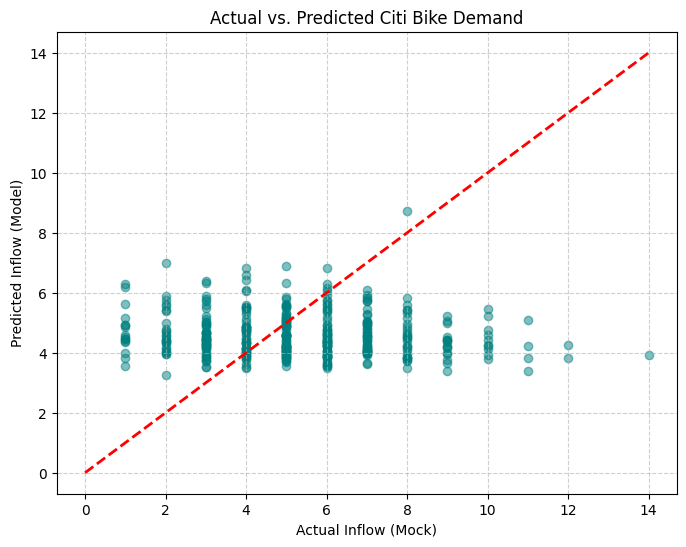

In [11]:
model.eval() # set to evaluation mode
with torch.no_grad():
    y_pred_t = model(x_test_t)
    y_pred = y_pred_t.numpy()

# compute RMSE
rmse = np.sqrt(np.mean((y_pred - y_test)**2))
print(f"\nNeural Net RMSE: {rmse:.4f}")

# visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([0, max(y_test)], [0, max(y_test)], 'r--', lw=2)
plt.xlabel("Actual Inflow (Mock)")
plt.ylabel("Predicted Inflow (Model)")
plt.title("Actual vs. Predicted Citi Bike Demand")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
"""
In the graph above, the dots represent the actual vs predicted inflow. If the predictions were completely accurate, then these lines would lie along the y=x red dashed line. Since the mock data is all random, there is no pattern to find so our model behaves as expected (ie noise/garbage in, noise/garbage out).
"""